# 02 — Exploratory Data Analysis

Tells a **business story** in four acts before any statistical modeling:

| Act | Narrative |
|---|---|
| **A** | *Who asks for a booster?* — Prove self-selection bias visually |
| **B** | *What actually drives churn?* — Expose confounders |
| **C** | *The Aha! Moment* — Stratified / Simpson's Paradox view |
| **D** | *Data health* — Mixed correlation heatmap before modeling |

**Input:** `processed/df_analysis.csv`

## Setup

In [35]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path

pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid", palette="muted")
PALETTE = {"No Booster": "#7fb3d3", "Has Booster": "#e87040"}

In [36]:
df = pd.read_csv(Path("processed/df_analysis.csv"))

# Restore ordered categoricals (CSV loses dtype)
df["internet_usage"] = pd.Categorical(
    df["internet_usage"],
    categories=["Low", "Medium", "High", "Extreme"],
    ordered=True,
)
df["age_group"] = pd.Categorical(
    df["age_group"].astype(str),
    categories=["18-25", "26-35", "36-50", "51-65", "66+"],
    ordered=True,
)

# Unordered categoricals
for col in ["commune", "gender", "tv_product", "mobile_product", "zip", "region"]:
    df[col] = df[col].astype("category")

# Display label column used across many plots
df["has_booster_label"] = df["has_booster"].map({0: "No Booster", 1: "Has Booster"})

print(f"Loaded {len(df):,} rows, {df.shape[1]} columns")
print("New enriched columns:", [c for c in ["age", "age_group", "region"] if c in df.columns])

Loaded 125,000 rows, 15 columns
New enriched columns: ['age', 'age_group', 'region']


---
## Act A — Selection Bias (Who asks for a booster?)

If treatment (`has_booster`) is not randomly assigned, the groups are systematically
different from the start. The three charts below confirm this is the case.

### Plot 1 — Booster Adoption Rates by Internet Usage Tier

**Hypothesis:** Heavy users request the booster far more often.
A 100 % stacked bar makes the adoption *rate* comparable across tiers of unequal size.

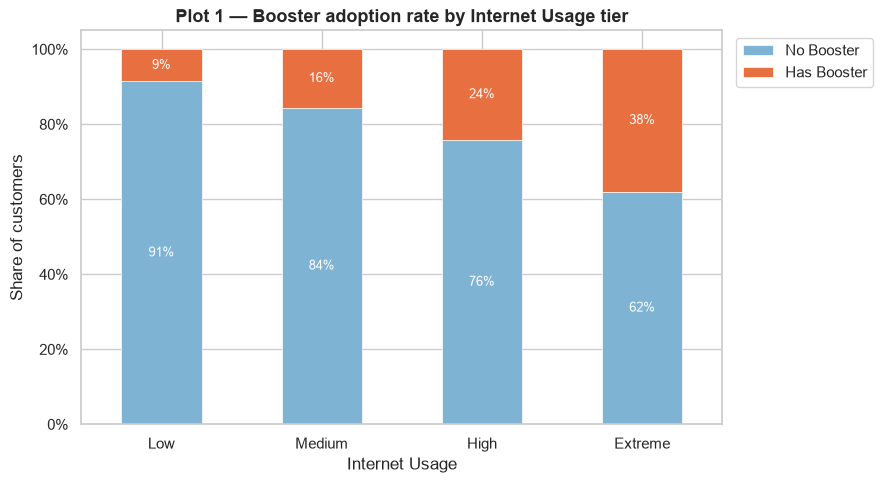

In [37]:
usage_order = ["Low", "Medium", "High", "Extreme"]

adoption = (
    df.groupby(["internet_usage", "has_booster_label"], observed=True)
      .size()
      .unstack(fill_value=0)
      .reindex(usage_order)
)
adoption_pct = adoption.div(adoption.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 5))
adoption_pct[["No Booster", "Has Booster"]].plot(
    kind="bar", stacked=True,
    color=[PALETTE["No Booster"], PALETTE["Has Booster"]],
    ax=ax, edgecolor="white", linewidth=0.5,
)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Plot 1 — Booster adoption rate by Internet Usage tier", fontsize=13, fontweight="bold")
ax.set_xlabel("Internet Usage")
ax.set_ylabel("Share of customers")
ax.set_xticklabels(usage_order, rotation=0)
ax.legend(title="", bbox_to_anchor=(1.01, 1), loc="upper left")
for bar_group in ax.containers:
    ax.bar_label(bar_group, fmt="%.0f%%", label_type="center", fontsize=9, color="white")
plt.tight_layout()
plt.show()

### Plot 2 — Booster Adoption by Commune (Urban vs Rural)

**Hypothesis:** Rural customers in larger homes may need boosters for coverage reasons,
independent of their loyalty or internet usage.

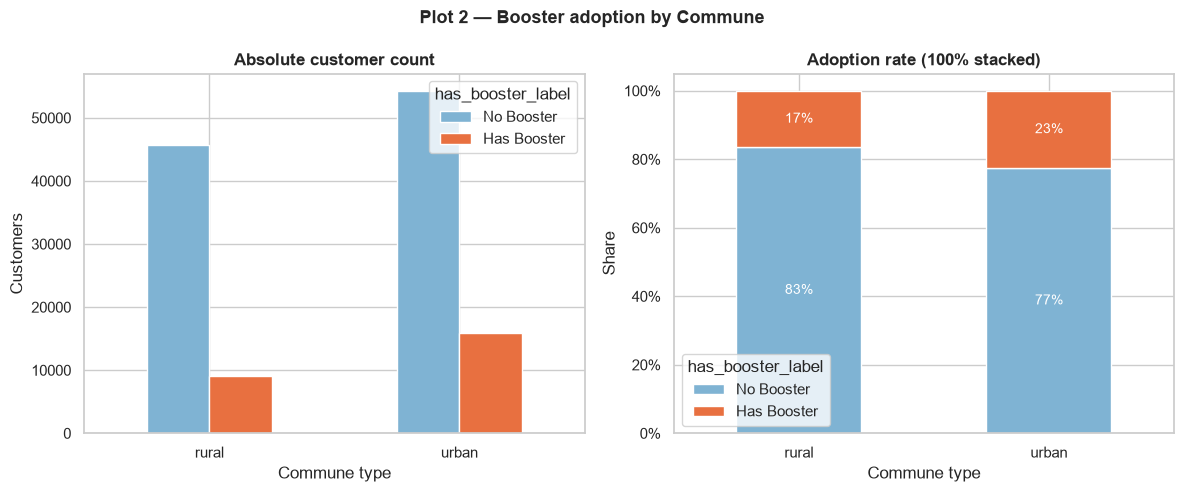

In [38]:
commune_adoption = (
    df.groupby(["commune", "has_booster_label"], observed=True)
      .size()
      .unstack(fill_value=0)
)
commune_pct = commune_adoption.div(commune_adoption.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: absolute counts
commune_adoption[["No Booster", "Has Booster"]].plot(
    kind="bar", color=[PALETTE["No Booster"], PALETTE["Has Booster"]],
    ax=axes[0], edgecolor="white"
)
axes[0].set_title("Absolute customer count", fontweight="bold")
axes[0].set_xlabel("Commune type")
axes[0].set_ylabel("Customers")
axes[0].set_xticklabels(commune_adoption.index, rotation=0)

# Right: adoption rate
commune_pct[["No Booster", "Has Booster"]].plot(
    kind="bar", stacked=True, color=[PALETTE["No Booster"], PALETTE["Has Booster"]],
    ax=axes[1], edgecolor="white"
)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_title("Adoption rate (100% stacked)", fontweight="bold")
axes[1].set_xlabel("Commune type")
axes[1].set_ylabel("Share")
axes[1].set_xticklabels(commune_pct.index, rotation=0)
for bar_group in axes[1].containers:
    axes[1].bar_label(bar_group, fmt="%.0f%%", label_type="center", fontsize=10, color="white")

fig.suptitle("Plot 2 — Booster adoption by Commune", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Plot 3 — Tenure Distributions: Booster vs No-Booster (Boxplot)

**Hypothesis:** Long-tenured, loyal customers are more aware of the free booster
offer. If true, any churn difference is partly a **tenure effect**, not a booster effect.

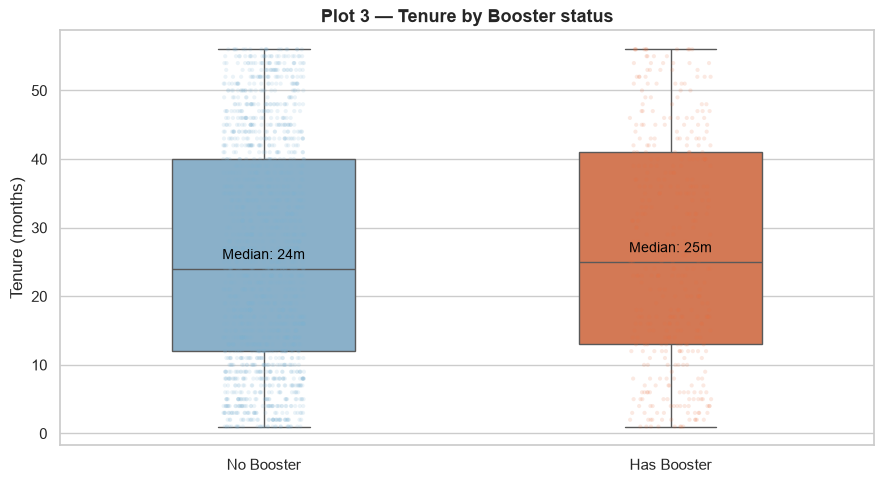

In [39]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="has_booster_label",
    y="tenure",
    hue="has_booster_label",
    order=["No Booster", "Has Booster"],
    hue_order=["No Booster", "Has Booster"],
    palette=PALETTE,
    legend=False,
    width=0.45,
    flierprops=dict(marker=".", alpha=0.3),
    ax=ax,
)
sns.stripplot(
    data=df.sample(min(2000, len(df)), random_state=42),
    x="has_booster_label",
    y="tenure",
    hue="has_booster_label",
    order=["No Booster", "Has Booster"],
    hue_order=["No Booster", "Has Booster"],
    palette=PALETTE,
    legend=False,
    alpha=0.15, size=3, jitter=True, ax=ax,
)
ax.set_title("Plot 3 — Tenure by Booster status", fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Tenure (months)")

for label, group in df.groupby("has_booster_label", observed=True):
    median = group["tenure"].median()
    x_pos = ["No Booster", "Has Booster"].index(label)
    ax.text(x_pos, median + 1, f"Median: {median:.0f}m", ha="center", va="bottom", fontsize=10, color="black")

plt.tight_layout()
plt.show()

---
## Act B — Identifying Baseline Churn Drivers (Confounders)

These variables predict churn *independently* of the booster.
If they are also correlated with booster adoption (**confounders**).

### Plot 4 — Bundle Stickiness: Churn Rate by TV × Mobile Product

Customers with richer bundles churn less — the "**Golden Handcuffs**" effect.
If bundled customers also request more boosters, analysis is capturing
bundle loyalty, not booster value.

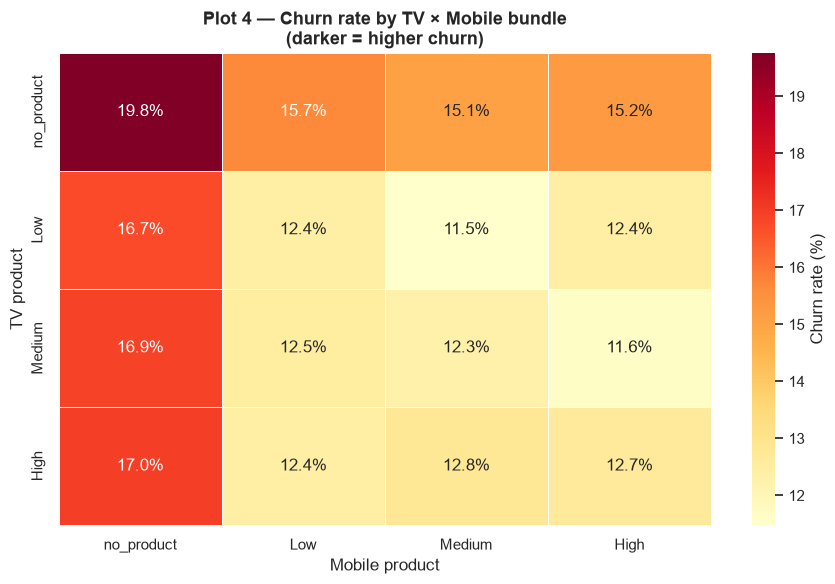

In [40]:
tv_order  = ["no_product", "Low", "Medium", "High"]
mob_order = ["no_product", "Low", "Medium", "High"]

bundle = (
    df.groupby(["tv_product", "mobile_product"], observed=True)["churned"]
      .agg(["mean", "count"])
      .reset_index()
)
pivot_churn = bundle.pivot(index="tv_product", columns="mobile_product", values="mean").reindex(index=tv_order, columns=mob_order)

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(
    pivot_churn * 100,
    annot=pivot_churn.map(lambda x: f"{x*100:.1f}%" if not pd.isna(x) else ""),
    fmt="",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Churn rate (%)"},
    ax=ax,
)
ax.set_title("Plot 4 — Churn rate by TV × Mobile bundle\n(darker = higher churn)", fontsize=13, fontweight="bold")
ax.set_xlabel("Mobile product")
ax.set_ylabel("TV product")
plt.tight_layout()
plt.show()

### Plot 5 — Tenure Cohorts vs Churn Rate (Life-stage Curve)

Early-life churn is high and flattens with tenure — a well-documented pattern. If booster adopters are disproportionately tenured, this capturing a **maturity effect**.

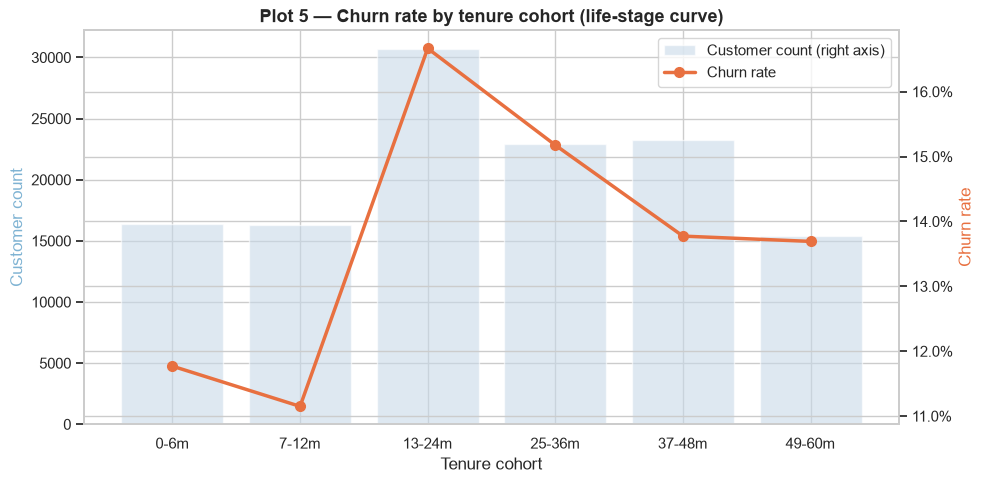

In [41]:
bins   = [0, 6, 12, 24, 36, 48, 60, 9999]
labels = ["0-6m", "7-12m", "13-24m", "25-36m", "37-48m", "49-60m", "60m+"]

df["tenure_bin"] = pd.cut(df["tenure"], bins=bins, labels=labels, right=True)

tenure_churn = (
    df.groupby("tenure_bin", observed=True)["churned"]
      .agg(["mean", "count"])
      .reset_index()
)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.bar(
    tenure_churn["tenure_bin"].astype(str),
    tenure_churn["count"],
    color="#c8d9e8", alpha=0.6, label="Customer count (right axis)",
)
ax2.plot(
    tenure_churn["tenure_bin"].astype(str),
    tenure_churn["mean"] * 100,
    color="#e87040", marker="o", linewidth=2.5, markersize=7, label="Churn rate",
)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.set_ylabel("Customer count", color="#7fb3d3")
ax2.set_ylabel("Churn rate", color="#e87040")
ax1.set_xlabel("Tenure cohort")
ax1.set_title("Plot 5 — Churn rate by tenure cohort (life-stage curve)", fontsize=13, fontweight="bold")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.show()

---
## Act C — Stratified View / Simpson's Paradox (The "Aha!" Moment)

> *"The overall booster effect looked great. But watch what happens when we control for usage tier."*

### Plot 6 — Churn Rate by Booster Status × Internet Usage (Stratified)

If the booster effect **shrinks or disappears** within each usage tier, the aggregate
gap was a **statistical illusion** caused by composition (Simpson's Paradox).

/var/folders/vq/j6mpg_0s6bq2nx9cm6dlt4zh0000gn/T/ipykernel_4082/3368633990.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


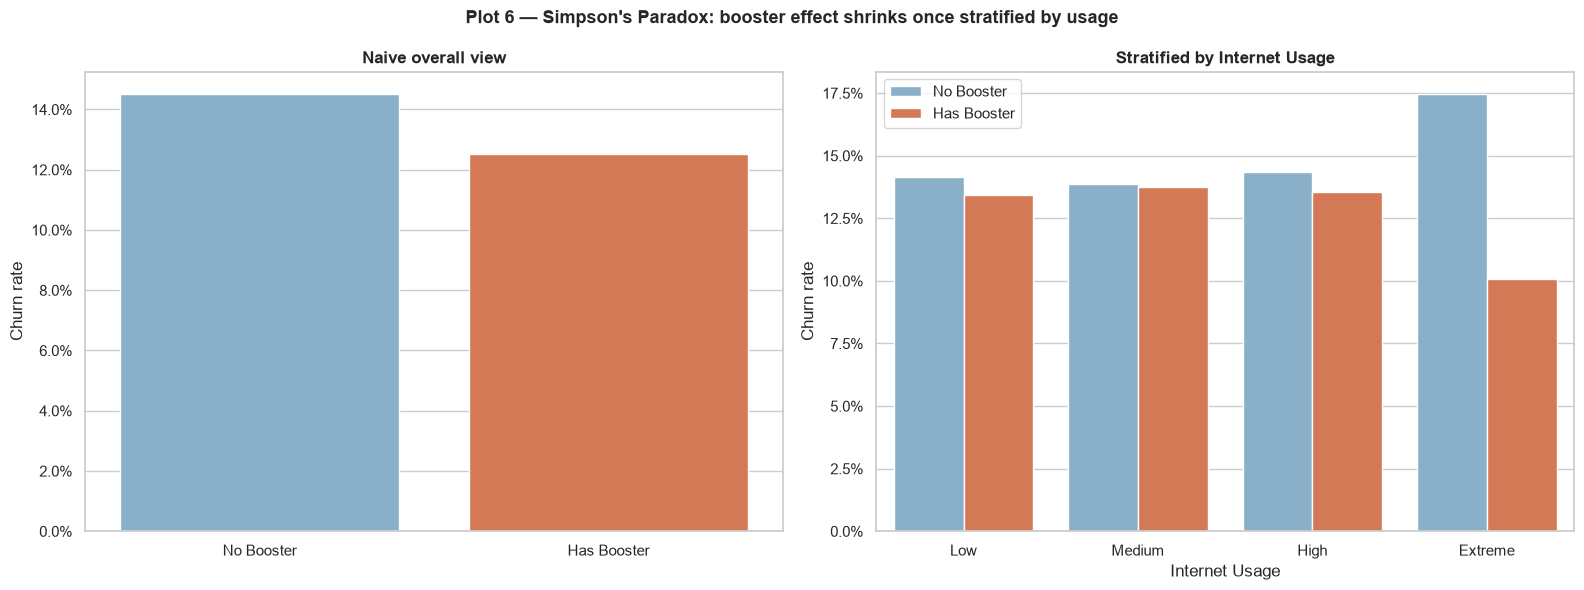


Stratified churn gap (Has Booster - No Booster) by usage tier:


has_booster_label,No Booster,Has Booster,gap (pp)
internet_usage,,,
Low,14.13%,13.42%,-0.71
Medium,13.87%,13.77%,-0.10
High,14.34%,13.56%,-0.77
Extreme,17.49%,10.08%,-7.40


In [42]:
overall_gap = df.groupby("has_booster_label", observed=True)["churned"].mean()

stratified = (
    df.groupby(["internet_usage", "has_booster_label"], observed=True)["churned"]
      .mean()
      .reset_index()
      .rename(columns={"churned": "churn_rate"})
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

# Left: naive overall
sns.barplot(
    data=df.groupby("has_booster_label", observed=True)["churned"]
           .mean().reset_index().rename(columns={"churned": "churn_rate"}),
    x="has_booster_label", y="churn_rate",
    order=["No Booster", "Has Booster"],
    palette=PALETTE, ax=axes[0],
)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[0].set_title("Naive overall view", fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Churn rate")

# Right: stratified by usage
sns.barplot(
    data=stratified,
    x="internet_usage", y="churn_rate",
    hue="has_booster_label", hue_order=["No Booster", "Has Booster"],
    order=["Low", "Medium", "High", "Extreme"],
    palette=PALETTE, ax=axes[1],
)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[1].set_title("Stratified by Internet Usage", fontweight="bold")
axes[1].set_xlabel("Internet Usage")
axes[1].set_ylabel("Churn rate")
axes[1].legend(title="")

fig.suptitle(
    "Plot 6 — Simpson's Paradox: booster effect shrinks once stratified by usage",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
plt.show()

print("\nStratified churn gap (Has Booster - No Booster) by usage tier:")
gap = (
    stratified.pivot(index="internet_usage", columns="has_booster_label", values="churn_rate")
              .assign(gap=lambda x: (x["Has Booster"] - x["No Booster"]) * 100)
              [["No Booster", "Has Booster", "gap"]]
              .rename(columns={"gap": "gap (pp)"})
)
gap.index = gap.index.astype(str)
display(gap.style.format({"No Booster": "{:.2%}", "Has Booster": "{:.2%}", "gap (pp)": "{:.2f}"}))

---
## Act D — Data Health: Mixed Correlation Heatmap

Before passing features to the logistic regression we check for **multicollinearity**.

- Binary ↔ continuous: **Point-Biserial r** (mathematically equivalent to Pearson for binary predictors)
- Categorical ↔ anything: **Cramér's V** (strength of association from chi-squared)
- Continuous ↔ continuous: **Pearson r**

We build a single symmetric matrix using the appropriate statistic per pair.

### Plot 7 — Mixed Correlation Heatmap

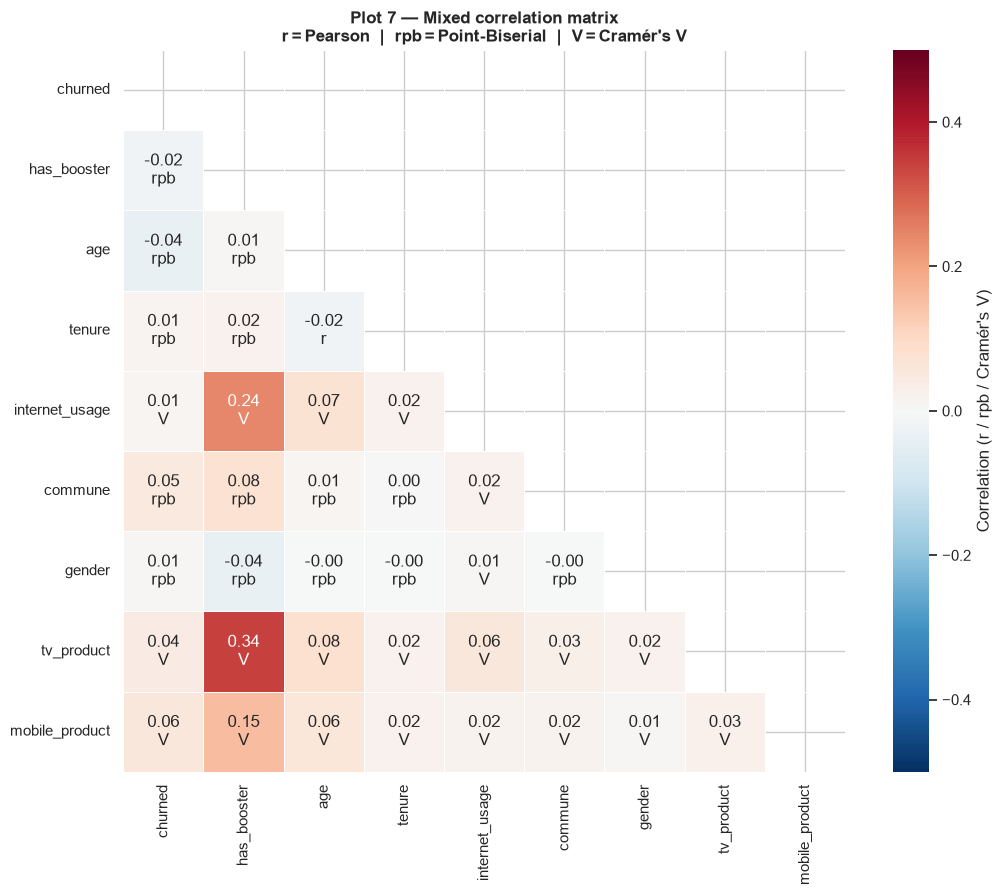

High-association pairs (|corr| > 0.3):
  has_booster          ↔ tv_product            0.341


In [43]:
from scipy.stats import pointbiserialr
from scipy.stats.contingency import association
from itertools import combinations

# Ordinal / numeric encoding for all features — cast everything to float
usage_map = {"Low": 0.0, "Medium": 1.0, "High": 2.0, "Extreme": 3.0}
tv_map    = {"no_product": 0.0, "Low": 1.0, "Medium": 2.0, "High": 3.0}
mob_map   = {"no_product": 0.0, "Low": 1.0, "Medium": 2.0, "High": 3.0}

enc = pd.DataFrame({
    "churned"        : df["churned"].astype(float),
    "has_booster"    : df["has_booster"].astype(float),
    "age"            : df["age"].astype(float),
    "tenure"         : df["tenure"].astype(float),
    "internet_usage" : df["internet_usage"].astype(str).map(usage_map),
    "commune"        : (df["commune"].astype(str) == "urban").astype(float),
    "gender"         : (df["gender"].astype(str) == "m").astype(float),
    "tv_product"     : df["tv_product"].astype(str).map(tv_map),
    "mobile_product" : df["mobile_product"].astype(str).map(mob_map),
}).dropna()

# Variable metadata
BINARY_COLS     = ["churned", "has_booster", "commune", "gender"]
CONTINUOUS_COLS = ["age", "tenure"]
ORDINAL_COLS    = ["internet_usage", "tv_product", "mobile_product"]

cols = list(enc.columns)
n = len(cols)
corr_matrix = pd.DataFrame(np.eye(n), index=cols, columns=cols)
method_matrix = pd.DataFrame("", index=cols, columns=cols)

for c1, c2 in combinations(cols, 2):
    x = enc[c1].to_numpy(dtype=float)
    y = enc[c2].to_numpy(dtype=float)
    mask = ~(np.isnan(x) | np.isnan(y))
    x, y = x[mask], y[mask]

    if c1 in ORDINAL_COLS or c2 in ORDINAL_COLS:
        ct = pd.crosstab(x.astype(int), y.astype(int))
        val = association(ct.values, method="cramer")
        method = "V"
    elif c1 in BINARY_COLS or c2 in BINARY_COLS:
        val, _ = pointbiserialr(x.astype(int), y)
        method = "rpb"
    else:
        val = float(np.corrcoef(x, y)[0, 1])
        method = "r"

    corr_matrix.loc[c1, c2] = val
    corr_matrix.loc[c2, c1] = val
    method_matrix.loc[c1, c2] = method
    method_matrix.loc[c2, c1] = method

corr_matrix = corr_matrix.astype(float)

# Annotations: value + method
annot = corr_matrix.map(lambda v: f"{v:.2f}") + "\n" + method_matrix

fig, ax = plt.subplots(figsize=(11, 9))
mask_upper = np.zeros_like(corr_matrix, dtype=bool)
mask_upper[np.triu_indices_from(mask_upper)] = True

sns.heatmap(
    corr_matrix,
    mask=mask_upper,
    annot=annot,
    fmt="",
    cmap="RdBu_r",
    center=0, vmin=-0.5, vmax=0.5,
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Correlation (r / rpb / Cram\u00e9r's V)"},
    ax=ax,
)
ax.set_title(
    "Plot 7 \u2014 Mixed correlation matrix\n"
    "r\u2009=\u2009Pearson  |  rpb\u2009=\u2009Point-Biserial  |  V\u2009=\u2009Cram\u00e9r's V",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
plt.show()

# Flag high-association pairs
high_pairs = [
    (c1, c2, corr_matrix.loc[c1, c2])
    for c1, c2 in combinations(cols, 2)
    if abs(corr_matrix.loc[c1, c2]) > 0.3
]
if high_pairs:
    print("High-association pairs (|corr| > 0.3):")
    for c1, c2, v in sorted(high_pairs, key=lambda x: -abs(x[2])):
        print(f"  {c1:20s} \u2194 {c2:20s}  {v:.3f}")
else:
    print("No pairs with |corr| > 0.3 \u2014 multicollinearity risk is low.")

---
## Act E — Age & Geography Dimensions

Two final checks that expose:
- **Non-linear churn by life stage** — does churn peak for young or old customers?
- **Regional churn heterogeneity** — are some Swiss cantons systematically stickier?

### Plot 8 — Non-linear Age Check: Churn Rate by Age Group

**Hypothesis:** Churn is not linear in age. Young customers (18–25) may churn quickly
after trial contracts; older customers (66+) may be less tech-savvy and therefore more
loyal. Including a linear age term in the logistic model may miss this shape.

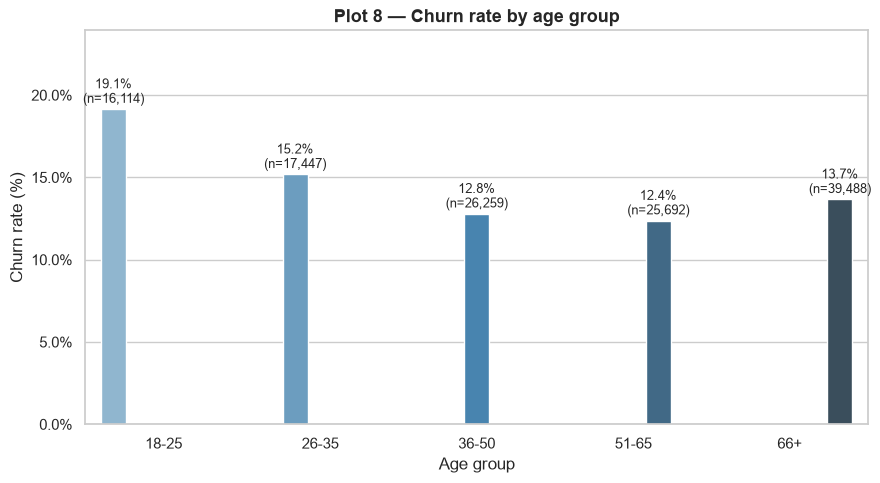

In [44]:
age_churn = (
    df.groupby("age_group", observed=True)["churned"]
      .agg(churn_rate="mean", n="count")
      .reset_index()
)
age_churn["churn_rate_pct"] = age_churn["churn_rate"] * 100

fig, ax = plt.subplots(figsize=(9, 5))

bars = sns.barplot(
    data=age_churn,
    x="age_group",
    y="churn_rate_pct",
    hue="age_group",
    palette="Blues_d",
    order=["18-25", "26-35", "36-50", "51-65", "66+"],
    legend=False,
    ax=ax,
)
# Annotate bars with rate and count
for patch, (_, row) in zip(ax.patches, age_churn.iterrows()):
    ax.text(
        patch.get_x() + patch.get_width() / 2,
        patch.get_height() + 0.15,
        f"{row['churn_rate_pct']:.1f}%\n(n={row['n']:,.0f})",
        ha="center", va="bottom", fontsize=9,
    )

ax.set_title("Plot 8 — Churn rate by age group", fontsize=13, fontweight="bold")
ax.set_xlabel("Age group")
ax.set_ylabel("Churn rate (%)")
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.1f%%"))
ax.set_ylim(0, age_churn["churn_rate_pct"].max() * 1.25)
plt.tight_layout()
plt.show()

### Plot 9 — Regional Churn: Average Churned Rate by Swiss Region

**Hypothesis:** Churn behaviour varies across Switzerland's 9 cantonal regions.
Urban cantons (Zürich, Lake Geneva) may show higher churn due to more competitive
telco markets; rural cantons (Graubünden, Eastern CH) may be stickier due to fewer
alternatives. Any significant regional variation would warrant ZIP-level controls in
the causal model.

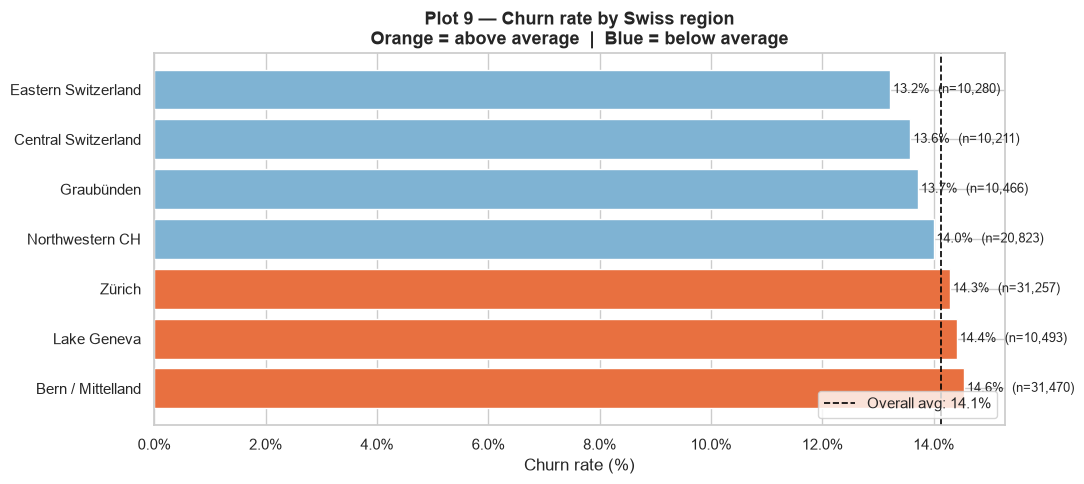

In [45]:
region_churn = (
    df.groupby("region", observed=True)["churned"]
      .agg(churn_rate="mean", n="count")
      .reset_index()
      .sort_values("churn_rate", ascending=False)
)
region_churn["churn_rate_pct"] = region_churn["churn_rate"] * 100

# Colour bars by whether churn is above/below overall average
overall_rate = df["churned"].mean() * 100
region_churn["color"] = region_churn["churn_rate_pct"].apply(
    lambda r: "#e87040" if r > overall_rate else "#7fb3d3"
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(
    region_churn["region"],
    region_churn["churn_rate_pct"],
    color=region_churn["color"],
    edgecolor="white",
)
ax.axvline(overall_rate, color="black", linewidth=1.2, linestyle="--",
           label=f"Overall avg: {overall_rate:.1f}%")

for i, (_, row) in enumerate(region_churn.iterrows()):
    ax.text(
        row["churn_rate_pct"] + 0.05,
        i,
        f"{row['churn_rate_pct']:.1f}%  (n={row['n']:,.0f})",
        va="center", ha="left", fontsize=9,
    )

ax.set_title(
    "Plot 9 — Churn rate by Swiss region\n"
    "Orange = above average  |  Blue = below average",
    fontsize=13, fontweight="bold",
)
ax.set_xlabel("Churn rate (%)")
ax.xaxis.set_major_formatter(mtick.FormatStrFormatter("%.1f%%"))
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## EDA plots and the business story they tell:

- **Plot 1** — 100% stacked bar by usage tier → Extreme users request booster 38% of the time vs 9% Low users (self-selection proved)
- **Plot 2** — Adoption by commune → Urban customers request it more than rural
- **Plot 3** — Tenure boxplot → Booster adopters have similar tenure (confounder exposed)
- **Plot 4** — TV × Mobile bundle heatmap → No-bundle customers churn at 20%, vs 12% for bundled (golden handcuffs)
- **Plot 5** — Life-stage curve → Churn peaks 13–24 months then falls (tenure effect)
- **Plot 6** — Simpson's Paradox → Naive gap was −2pp overall, but only −0.1pp within Medium usage and −7.4pp within Extreme only
- **Plot 7** — Mixed correlation heatmap (Pearson / Point-Biserial / Cramér's V) → has_booster ↔ tv_product V=0.34, the key confounder for the logistic model
- **Plot 8** — Non-linear Age Check: U-shaped churn curve — young customers (18–25: 19.1%) churn most, drops sharply to 51–65 (12.4%), then rises slightly at 66+ (13.7%). Implication: a linear age term in the logit model would not capture this; the age_group dummy approach is preferable.
- **Plot 9** — Regional Churn: Bern/Mittelland (14.6%), Lake Geneva (14.4%), and Zürich (14.3%) are above the 14.1% average; Eastern Switzerland (13.2%) and Central Switzerland (13.6%) are below. Regional variation is modest (~1.4pp range) but real.